Dataset Link:
https://data.mendeley.com/datasets/x8ygrw87jw/1

Importing Necessary Libraries.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
from pandas.plotting import parallel_coordinates, andrews_curves, lag_plot
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE

Displaying dataset shape to understand dimensions and size.

In [ ]:
df = pd.read_csv('/content/dataset.csv')
print("Shape of the Dataset Is: ",df.shape)
print("dataset preview is: ")
df.head(10)

Shape of the Dataset Is:  (43400, 12)
dataset preview is: 


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0
5,32257,Female,47.0,0,0,Yes,Private,Urban,210.95,50.1,NaN,0
6,52800,Female,52.0,0,0,Yes,Private,Urban,77.59,17.7,formerly smoked,0
7,41413,Female,75.0,0,1,Yes,Self-employed,Rural,243.53,27.0,never smoked,0
8,15266,Female,32.0,0,0,Yes,Private,Rural,77.67,32.3,smokes,0
9,28674,Female,74.0,1,0,Yes,Self-employed,Urban,205.84,54.6,never smoked,0


Checking the last 10 rows of the dataset.

In [ ]:
print("Dataset Preview for the last rows: ")
df.tail(10)

Dataset Preview for the last rows: 


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
43390,10096,Female,69.0,0,0,Yes,Self-employed,Urban,229.85,31.2,never smoked,0
43391,30077,Male,6.0,0,0,No,children,Urban,77.48,19.1,NaN,0
43392,45266,Female,18.0,0,0,No,Private,Urban,131.96,22.8,NaN,0
43393,69344,Male,39.0,0,0,Yes,Private,Rural,132.22,31.6,never smoked,0
43394,52380,Male,47.0,0,0,No,Govt_job,Urban,68.52,25.2,formerly smoked,0
43395,56196,Female,10.0,0,0,No,children,Urban,58.64,20.4,never smoked,0
43396,5450,Female,56.0,0,0,Yes,Govt_job,Urban,213.61,55.4,formerly smoked,0
43397,28375,Female,82.0,1,0,Yes,Private,Urban,91.94,28.9,formerly smoked,0
43398,27973,Male,40.0,0,0,Yes,Private,Urban,99.16,33.2,never smoked,0
43399,36271,Female,82.0,0,0,Yes,Private,Urban,79.48,20.6,never smoked,0


Checking the column list and showing the list.

In [ ]:
cols = df.columns.tolist()
print("Dataset Column Names:\n")
for i in range(0, len(cols), 3):
    print(" | ".join(cols[i:i+3]))

Dataset Column Names:

id | gender | age
hypertension | heart_disease | ever_married
work_type | Residence_type | avg_glucose_level
bmi | smoking_status | stroke


Displaying the datatypes of the dataset.

In [ ]:
print("\nData Types:")
print(df.dtypes)


Data Types:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


Checking the info of the dataset.


In [ ]:
print("Info of the Dataset is: ")
df.info()

Info of the Dataset is: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  object 
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  int64  
 4   heart_disease      43400 non-null  int64  
 5   ever_married       43400 non-null  object 
 6   work_type          43400 non-null  object 
 7   Residence_type     43400 non-null  object 
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                41938 non-null  float64
 10  smoking_status     30108 non-null  object 
 11  stroke             43400 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 4.0+ MB


Checking the missing values of the dataset.

In [ ]:
print("Missing values : ")
df.isnull().sum()

Missing values : 


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,1462


Handling missing values by imputing median and replacing categories.

In [ ]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
df['smoking_status'] = df['smoking_status'].fillna('Unknown')
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


Checking the duplicate rows and displaying that.

In [ ]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


Finding Descriptive Statistics and showing that.

In [ ]:
print('Descriptive Statistics Is: ')
df.describe()

Descriptive Statistics Is: 


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000
mean,36326.142350,42.217894,0.093571,0.047512,104.482750,28.574551,0.018041
std,21072.134879,22.519649,0.291235,0.212733,43.111751,7.639769,0.133103
min,1.000000,0.080000,0.000000,0.000000,55.000000,10.100000,0.000000
25%,18038.500000,24.000000,0.000000,0.000000,77.540000,23.400000,0.000000
50%,36351.500000,44.000000,0.000000,0.000000,91.580000,27.700000,0.000000
75%,54514.250000,60.000000,0.000000,0.000000,112.070000,32.600000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,291.050000,97.600000,1.000000


Finding unique values.

In [ ]:
for col in df.columns:
    print(f"{col} → {df[col].nunique()} unique values")

id → 43400 unique values
gender → 3 unique values
age → 104 unique values
hypertension → 2 unique values
heart_disease → 2 unique values
ever_married → 2 unique values
work_type → 5 unique values
Residence_type → 2 unique values
avg_glucose_level → 12543 unique values
bmi → 555 unique values
smoking_status → 4 unique values
stroke → 2 unique values


Identifying categorical and numerical columns based on data types.

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')
Numerical: Index(['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level',
       'bmi', 'stroke'],
      dtype='object')


Analyzing stroke class distribution using counts and normalized proportions.

In [ ]:
print(df['stroke'].value_counts())
print(df['stroke'].value_counts(normalize=True))

stroke
0    42617
1      783
Name: count, dtype: int64
stroke
0    0.981959
1    0.018041
Name: proportion, dtype: float64


Visualizing stroke class distribution using countplot and annotated labels.

/tmp/ipykernel_1343/690293534.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='stroke', data=df, palette=colors)


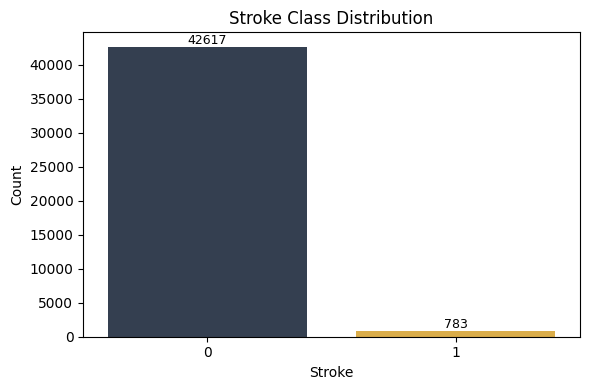

In [ ]:
plt.figure(figsize=(6,4))
colors = ["#2f3e55", "#f2b632"]
ax = sns.countplot(x='stroke', data=df, palette=colors)
# Adding labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.title("Stroke Class Distribution", fontsize=12)
plt.xlabel("Stroke", fontsize=10)
plt.ylabel("Count", fontsize=10)
plt.tight_layout()
plt.show()

Plotting ECDF of age distribution grouped by stroke status.

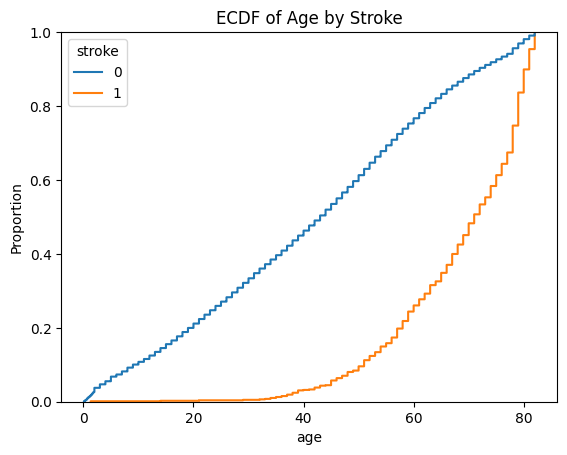

In [ ]:
# ECDF PLOT
plt.figure()
sns.ecdfplot(data=df, x="age", hue="stroke")
plt.title("ECDF of Age by Stroke")
plt.show()

Visualizing glucose distribution using KDE plot with rug plot.

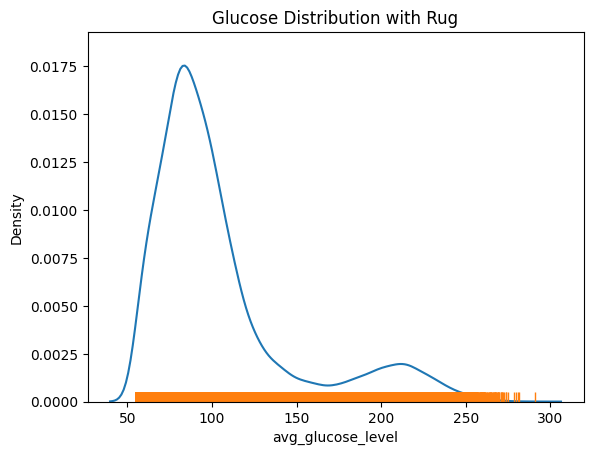

In [ ]:
# RUG PLOT
plt.figure()
sns.kdeplot(df['avg_glucose_level'])
sns.rugplot(df['avg_glucose_level'])
plt.title("Glucose Distribution with Rug")
plt.show()

Comparing mean glucose levels across stroke categories using pointplot.

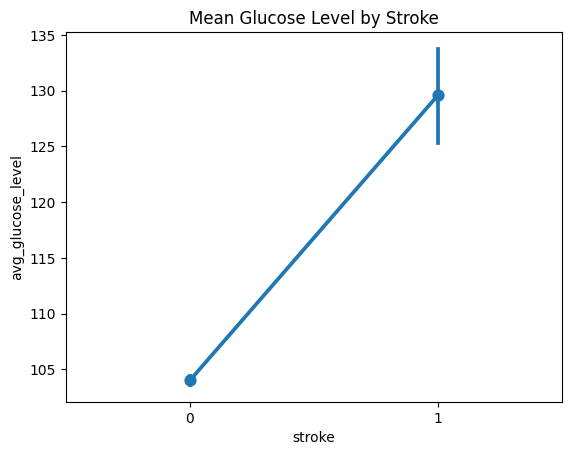

In [ ]:
# POINT PLOT (Mean Comparison)
plt.figure()
sns.pointplot(x='stroke', y='avg_glucose_level', data=df)
plt.title("Mean Glucose Level by Stroke")
plt.show()

Visualizing work type distribution by stroke using countplot with hue.

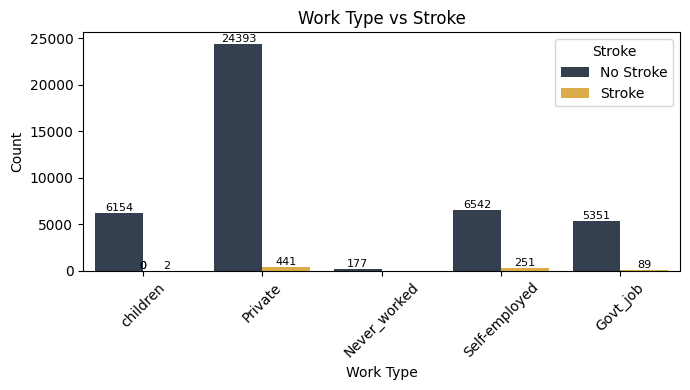

In [ ]:
# # COUNT PLOT WITH HUE (Multi-category)
plt.figure(figsize=(7,4))
ax = sns.countplot(x='work_type', hue='stroke', data=df,
                   palette=["#2f3e55", "#f2b632"])
# Adding labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.title("Work Type vs Stroke", fontsize=12)
plt.xlabel("Work Type", fontsize=10)
plt.ylabel("Count", fontsize=10)
plt.xticks(rotation=45)
plt.legend(title="Stroke", labels=["No Stroke", "Stroke"])
plt.tight_layout()
plt.show()

Exploring relationship between age and BMI using jointplot regression.

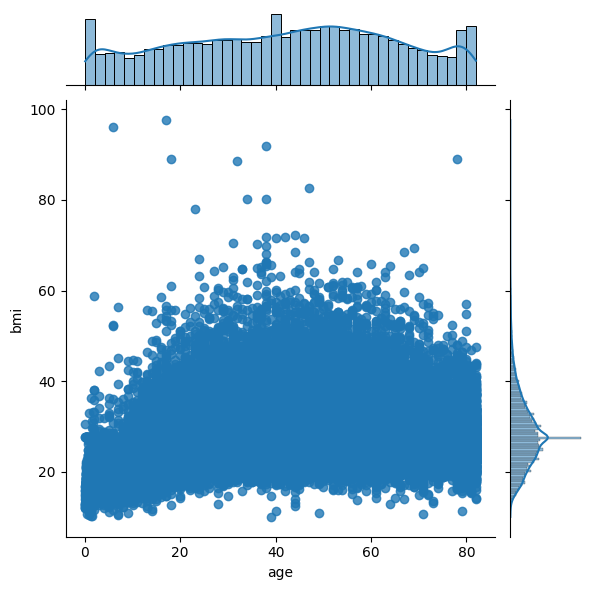

In [ ]:
# JOINT PLOT
sns.jointplot(x='age', y='bmi', data=df, kind='reg')
plt.show()

Encoding categorical features and visualizing correlations using heatmap matrix.

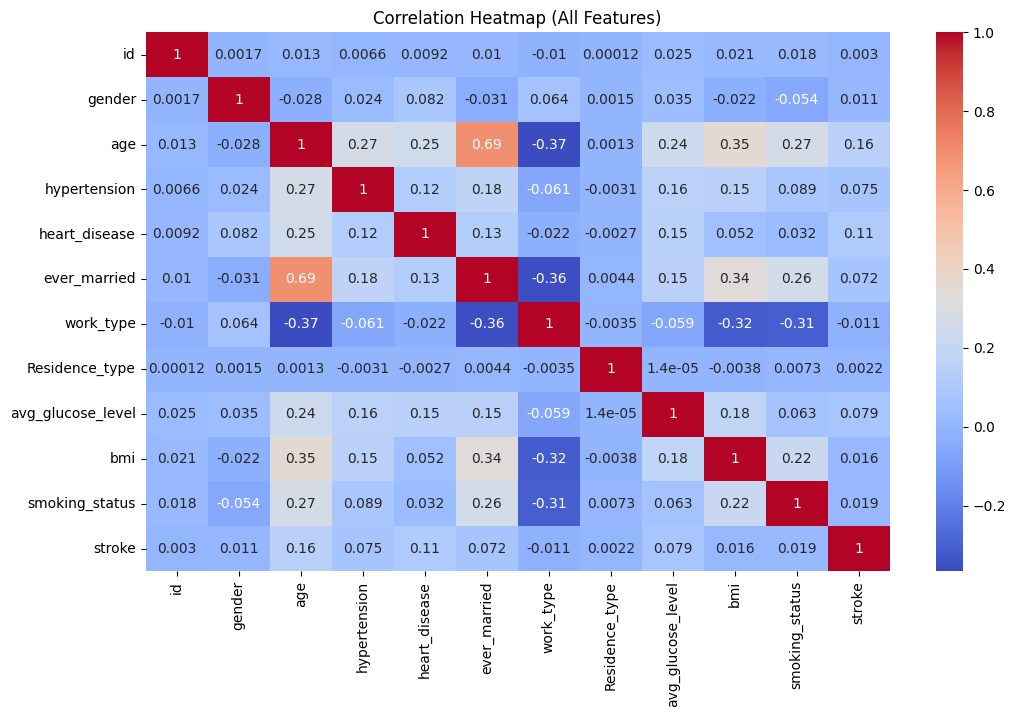

In [ ]:
# CLUSTERMAP (Feature Grouping)
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])
corr = df_encoded.corr()
plt.figure(figsize=(12,7))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (All Features)")
plt.show()

Visualizing feature relationships across stroke classes using parallel coordinates.

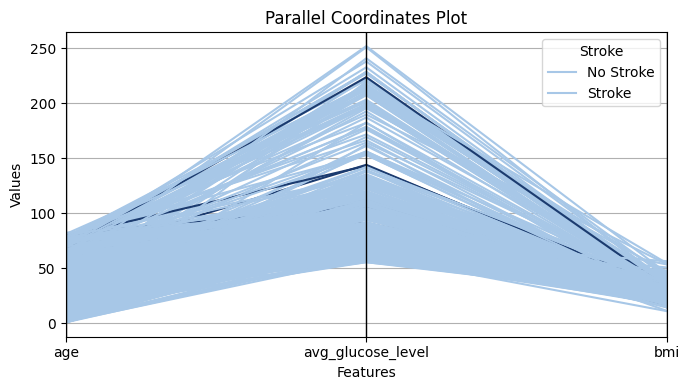

In [ ]:
# PARALLEL COORDINATES
sample_df = df[['age','avg_glucose_level','bmi','stroke']].dropna().sample(500)
plt.figure(figsize=(7,4))
parallel_coordinates(sample_df, 'stroke',
                     color=["#a7c7e7", "#1b3b6f"])
plt.title("Parallel Coordinates Plot", fontsize=12)
plt.xlabel("Features", fontsize=10)
plt.ylabel("Values", fontsize=10)
plt.legend(title="Stroke", labels=["No Stroke", "Stroke"])
plt.tight_layout()
plt.show()

Comparing risk profiles using radar chart across stroke categories.

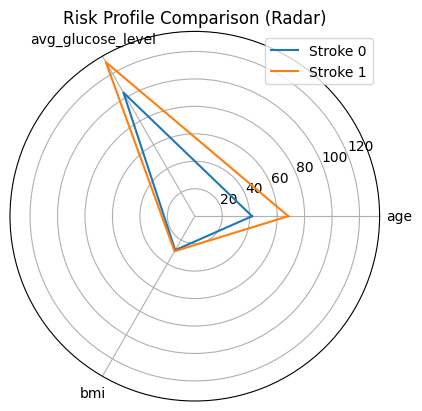

In [ ]:
# RADAR CHART (Risk Profile)
means = df.groupby('stroke')[['age','avg_glucose_level','bmi']].mean()
labels = means.columns
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
fig = plt.figure()
ax = fig.add_subplot(111, polar=True)
for i, row in means.iterrows():
    values = row.values
    values = np.concatenate((values, [values[0]]))
    ang = np.concatenate((angles, [angles[0]]))
    ax.plot(ang, values, label=f"Stroke {i}")

ax.set_thetagrids(angles * 180/np.pi, labels)
plt.title("Risk Profile Comparison (Radar)")
plt.legend()
plt.show()

Visualizing multidimensional data patterns using Andrews curves across stroke classes.

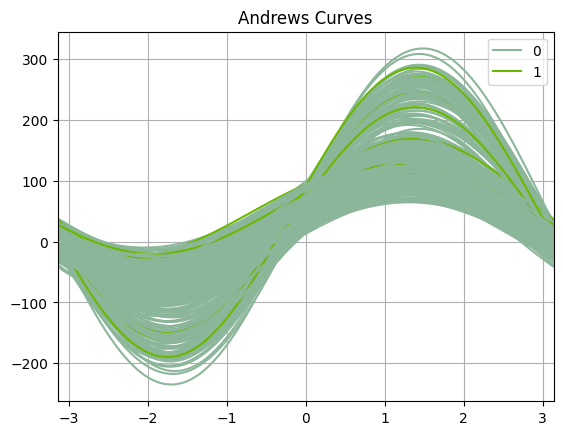

In [ ]:
sample = df[['age','avg_glucose_level','bmi','stroke']].dropna().sample(500)
plt.figure()
andrews_curves(sample, 'stroke')
plt.title("Andrews Curves")
plt.show()

Analyzing glucose value dependencies using lag plot visualization.

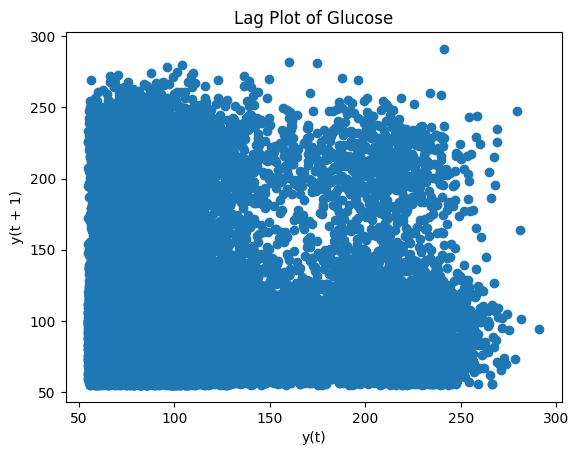

In [ ]:
plt.figure()
lag_plot(df['avg_glucose_level'])
plt.title("Lag Plot of Glucose")
plt.show()

Visualizing work type and stroke relationship using heatmap visualization.

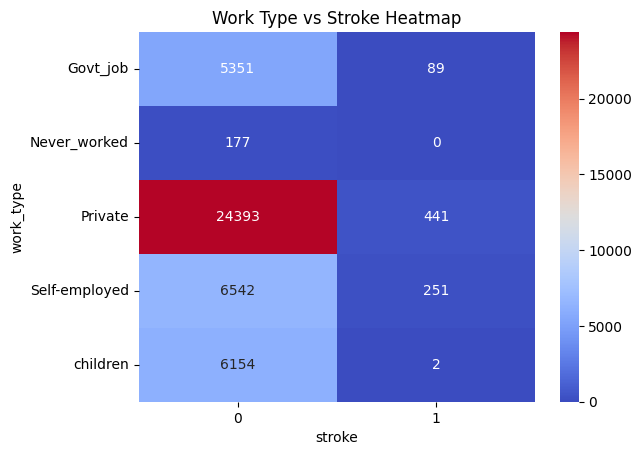

In [ ]:
pivot = pd.crosstab(df['work_type'], df['stroke'])
sns.heatmap(pivot, annot=True, fmt='d', cmap='coolwarm')
plt.title("Work Type vs Stroke Heatmap")
plt.show()

Dropping unnecessary columns and identifying continuous features based on uniqueness.

In [ ]:
df = df.drop('id', axis=1)
continuous_cols = []
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        if df[col].nunique() > 10 and col != 'stroke':
            continuous_cols.append(col)
print("Continuous Columns:", continuous_cols)

Continuous Columns: ['age', 'avg_glucose_level', 'bmi']


Detecting outliers using IQR method and counting extreme values.

In [ ]:
outlier_data = []
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_data.append([col, count])
outlier_df = pd.DataFrame(outlier_data, columns=["Feature", "Outlier Count"])
print(outlier_df)

             Feature  Outlier Count
0                age              0
1  avg_glucose_level           4978
2                bmi           1084


Visualizing feature distributions and outliers using boxplot before treatment.

/tmp/ipykernel_1343/2020766421.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


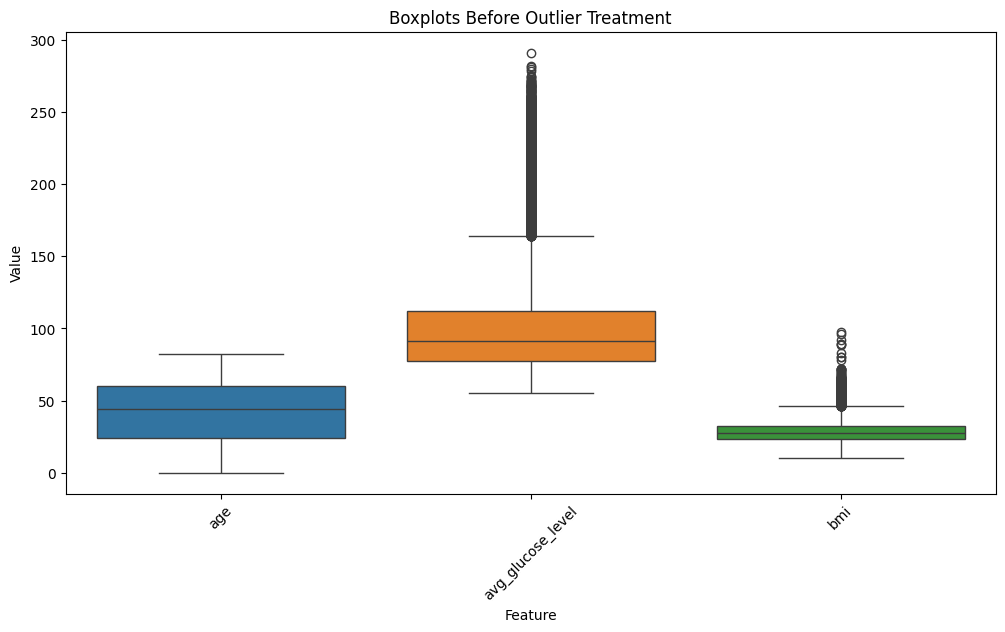

In [ ]:
plt.figure(figsize=(12,6))
df_melted = df[continuous_cols].melt(var_name='Feature', value_name='Value')
sns.boxplot(
    x='Feature',
    y='Value',
    data=df_melted,
    palette='tab10'
)
plt.title("Boxplots Before Outlier Treatment")
plt.xticks(rotation=45)
plt.show()

Handling outliers by clipping values within interquartile range limits.

In [ ]:
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

Comparing feature distributions after handling outliers using boxplot visualization.

/tmp/ipykernel_1343/387589234.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


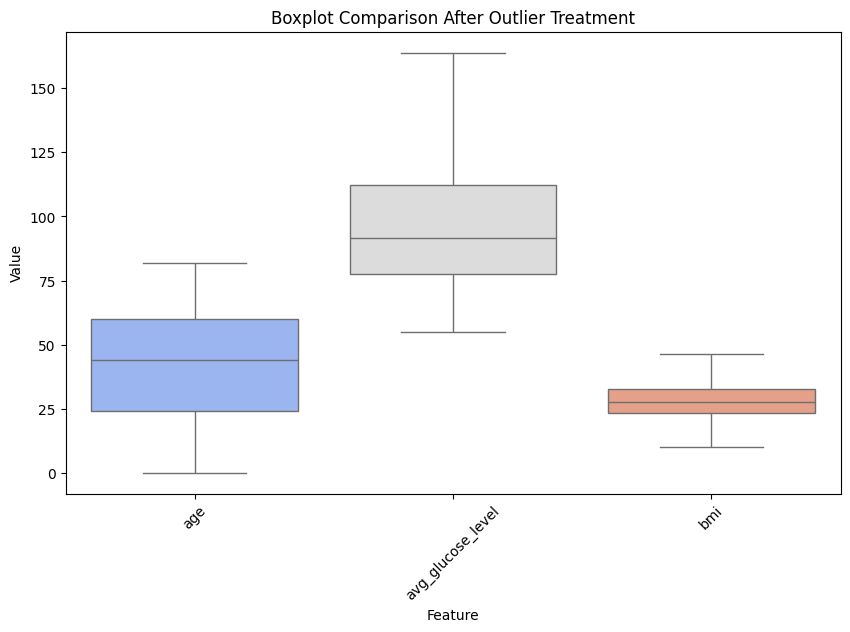

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Feature",
    y="Value",
    data=df[continuous_cols].melt(var_name="Feature", value_name="Value"),
    palette="coolwarm"
)

plt.title("Boxplot Comparison After Outlier Treatment")
plt.xticks(rotation=45)
plt.show()

Encoding categorical variables using label encoding for model compatibility.

In [ ]:
# ENCODING
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

Separating features and target, splitting dataset into training and testing.

In [ ]:
# FEATURE & TARGET
X = df.drop('stroke', axis=1)
y = df['stroke']
# TRAIN-TEST SPLITTING
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Scaling features using StandardScaler for improved model performance.

In [ ]:
# SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Handling class imbalance using SMOTE for balanced training dataset.

In [ ]:
# SMOTE (IMBALANCE HANDLING)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_sm))

Before SMOTE: [34094   626]
After SMOTE: [34094 34094]


Tuning Logistic Regression model using GridSearchCV and evaluating performance.

In [ ]:
param_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}
grid_lr = GridSearchCV(LogisticRegression(), param_lr, cv=3, scoring='f1')
grid_lr.fit(X_train_sm, y_train_sm)
best_lr = grid_lr.best_estimator_
print("Best LR Params:", grid_lr.best_params_)
y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:,1]
print("Logistic Regression (Tuned)\n")
print(classification_report(y_test, y_pred_lr))

Best LR Params: {'C': 0.01, 'solver': 'liblinear'}
Logistic Regression (Tuned)

              precision    recall  f1-score   support

           0       0.99      0.75      0.85      8523
           1       0.05      0.78      0.10       157

    accuracy                           0.75      8680
   macro avg       0.52      0.77      0.48      8680
weighted avg       0.98      0.75      0.84      8680



Visualizing confusion matrix to evaluate classification performance and errors.

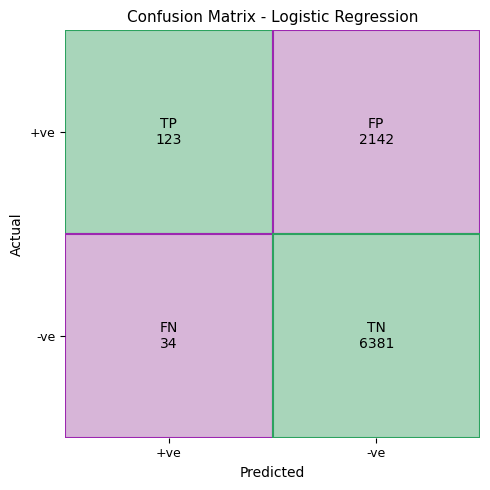

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)
TN, FP, FN, TP = cm.ravel()
fig, ax = plt.subplots(figsize=(5,5))
correct_color = "#a8d5ba"
error_color = "#d7b5d8"
edge_green = "#2ca25f"
edge_purple = "#9c27b0"
# TP
ax.add_patch(patches.Rectangle((0,1), 1, 1, facecolor=correct_color, edgecolor=edge_green, linewidth=1.5))
ax.text(0.5, 1.5, f"TP\n{TP}", ha='center', va='center', fontsize=10)
# FP
ax.add_patch(patches.Rectangle((1,1), 1, 1, facecolor=error_color, edgecolor=edge_purple, linewidth=1.5))
ax.text(1.5, 1.5, f"FP\n{FP}", ha='center', va='center', fontsize=10)
# FN
ax.add_patch(patches.Rectangle((0,0), 1, 1, facecolor=error_color, edgecolor=edge_purple, linewidth=1.5))
ax.text(0.5, 0.5, f"FN\n{FN}", ha='center', va='center', fontsize=10)
# TN
ax.add_patch(patches.Rectangle((1,0), 1, 1, facecolor=correct_color, edgecolor=edge_green, linewidth=1.5))
ax.text(1.5, 0.5, f"TN\n{TN}", ha='center', va='center', fontsize=10)
# Labels
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(['+ve', '-ve'], fontsize=9)
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(['-ve', '+ve'], fontsize=9)
ax.set_xlabel("Predicted", fontsize=10)
ax.set_ylabel("Actual", fontsize=10)
ax.set_title("Confusion Matrix - Logistic Regression", fontsize=11)
ax.set_xlim(0,2)
ax.set_ylim(0,2)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

Plotting ROC curve and evaluating model performance using AUC.

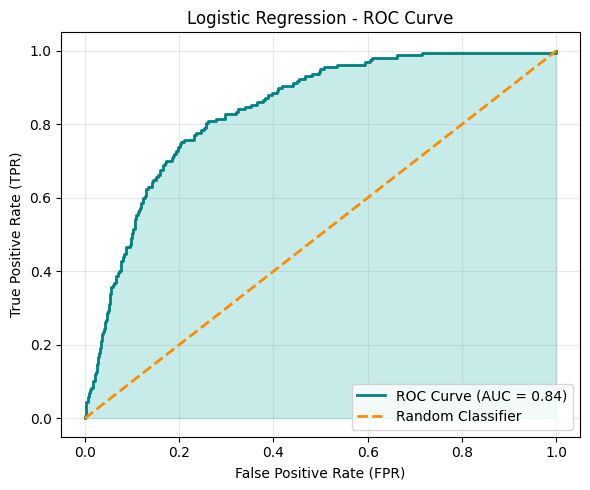

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr_lr, tpr_lr)
plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, color='#008080', linewidth=2,
         label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr_lr, tpr_lr, color='#20b2aa', alpha=0.25)
plt.plot([0,1], [0,1], color='#ff8c00', linestyle='--', linewidth=2,
         label='Random Classifier')
# Labels & title
plt.title("Logistic Regression - ROC Curve", fontsize=12)
plt.xlabel("False Positive Rate (FPR)", fontsize=10)
plt.ylabel("True Positive Rate (TPR)", fontsize=10)
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Tuning Random Forest model using GridSearchCV and evaluating classification performance.

In [ ]:
param_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(), param_rf, cv=3, scoring='f1')
grid_rf.fit(X_train_sm, y_train_sm)
best_rf = grid_rf.best_estimator_
print("Best RF Params:", grid_rf.best_params_)
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:,1]
print("Random Forest (Tuned)\n")
print(classification_report(y_test, y_pred_rf))

Best RF Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Random Forest (Tuned)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      8523
           1       0.07      0.08      0.08       157

    accuracy                           0.96      8680
   macro avg       0.53      0.53      0.53      8680
weighted avg       0.97      0.96      0.96      8680



Visualizing confusion matrix for Random Forest model using labeled plot.

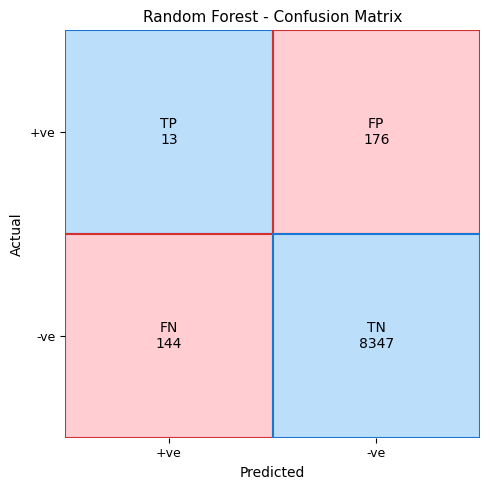

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
TN, FP, FN, TP = cm.ravel()
fig, ax = plt.subplots(figsize=(5,5))
correct_color = "#bbdefb"
error_color = "#ffcdd2"
edge_correct = "#1976d2"
edge_error = "#d32f2f"
# TP
ax.add_patch(patches.Rectangle((0,1), 1, 1, facecolor=correct_color, edgecolor=edge_correct, linewidth=1.5))
ax.text(0.5, 1.5, f"TP\n{TP}", ha='center', va='center', fontsize=10)
# FP
ax.add_patch(patches.Rectangle((1,1), 1, 1, facecolor=error_color, edgecolor=edge_error, linewidth=1.5))
ax.text(1.5, 1.5, f"FP\n{FP}", ha='center', va='center', fontsize=10)
# FN
ax.add_patch(patches.Rectangle((0,0), 1, 1, facecolor=error_color, edgecolor=edge_error, linewidth=1.5))
ax.text(0.5, 0.5, f"FN\n{FN}", ha='center', va='center', fontsize=10)
# TN
ax.add_patch(patches.Rectangle((1,0), 1, 1, facecolor=correct_color, edgecolor=edge_correct, linewidth=1.5))
ax.text(1.5, 0.5, f"TN\n{TN}", ha='center', va='center', fontsize=10)
# Labels
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(['+ve', '-ve'], fontsize=9)
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(['-ve', '+ve'], fontsize=9)
ax.set_xlabel("Predicted", fontsize=10)
ax.set_ylabel("Actual", fontsize=10)
ax.set_title("Random Forest - Confusion Matrix", fontsize=11)
ax.set_xlim(0,2)
ax.set_ylim(0,2)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

Plotting ROC curve for Random Forest and evaluating AUC performance.

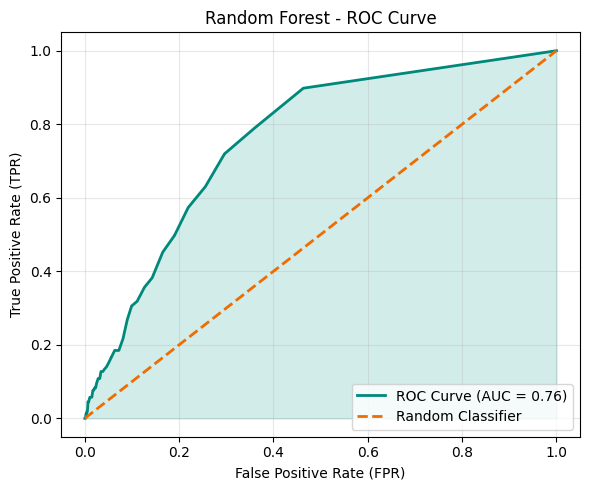

In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr_rf, tpr_rf)
plt.figure(figsize=(6,5))
# ROC curve
plt.plot(fpr_rf, tpr_rf,
         color='#00897b', linewidth=2,
         label=f'ROC Curve (AUC = {roc_auc:.2f})')
# Fill area
plt.fill_between(fpr_rf, tpr_rf,
                 color='#4db6ac', alpha=0.25)
plt.plot([0,1], [0,1],
         color='#ef6c00', linestyle='--', linewidth=2,
         label='Random Classifier')
# Labels & title
plt.title("Random Forest - ROC Curve", fontsize=12)
plt.xlabel("False Positive Rate (FPR)", fontsize=10)
plt.ylabel("True Positive Rate (TPR)", fontsize=10)
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Tuning Gradient Boosting model using GridSearchCV and evaluating performance.

In [ ]:
param_gb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}
grid_gb = GridSearchCV(GradientBoostingClassifier(), param_gb, cv=3, scoring='f1')
grid_gb.fit(X_train_sm, y_train_sm)
best_gb = grid_gb.best_estimator_
print("Best GB Params:", grid_gb.best_params_)
y_pred_gb = best_gb.predict(X_test)
y_prob_gb = best_gb.predict_proba(X_test)[:,1]
print("Gradient Boosting (Tuned)\n")
print(classification_report(y_test, y_pred_gb))

Best GB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Gradient Boosting (Tuned)

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      8523
           1       0.08      0.23      0.12       157

    accuracy                           0.94      8680
   macro avg       0.53      0.59      0.54      8680
weighted avg       0.97      0.94      0.95      8680



Visualizing confusion matrix for Gradient Boosting using labeled plot.

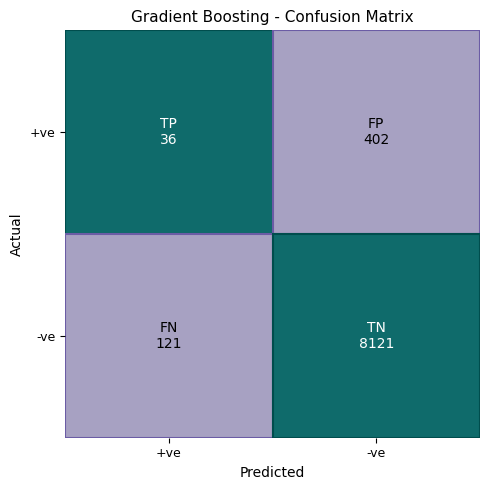

In [ ]:
cm = confusion_matrix(y_test, y_pred_gb)
TN, FP, FN, TP = cm.ravel()
fig, ax = plt.subplots(figsize=(5,5))
correct_color = "#0f6b6b"
error_color = "#a7a1c2"
edge_correct = "#004d4d"
edge_error = "#6b5ca5"
# TP (correct)
ax.add_patch(patches.Rectangle((0,1), 1, 1,
                               facecolor=correct_color,
                               edgecolor=edge_correct, linewidth=1.5))
ax.text(0.5, 1.5, f"TP\n{TP}", ha='center', va='center',
        fontsize=10, color='white')
# FP (error)
ax.add_patch(patches.Rectangle((1,1), 1, 1,
                               facecolor=error_color,
                               edgecolor=edge_error, linewidth=1.5))
ax.text(1.5, 1.5, f"FP\n{FP}", ha='center', va='center',
        fontsize=10)
# FN (error)
ax.add_patch(patches.Rectangle((0,0), 1, 1,
                               facecolor=error_color,
                               edgecolor=edge_error, linewidth=1.5))
ax.text(0.5, 0.5, f"FN\n{FN}", ha='center', va='center',
        fontsize=10)
# TN (correct)
ax.add_patch(patches.Rectangle((1,0), 1, 1,
                               facecolor=correct_color,
                               edgecolor=edge_correct, linewidth=1.5))
ax.text(1.5, 0.5, f"TN\n{TN}", ha='center', va='center',
        fontsize=10, color='white')

# Labels
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(['+ve', '-ve'], fontsize=9)
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(['-ve', '+ve'], fontsize=9)
ax.set_xlabel("Predicted", fontsize=10)
ax.set_ylabel("Actual", fontsize=10)
ax.set_title("Gradient Boosting - Confusion Matrix", fontsize=11)
ax.set_xlim(0,2)
ax.set_ylim(0,2)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

Plotting ROC curve for Gradient Boosting and evaluating AUC performance.

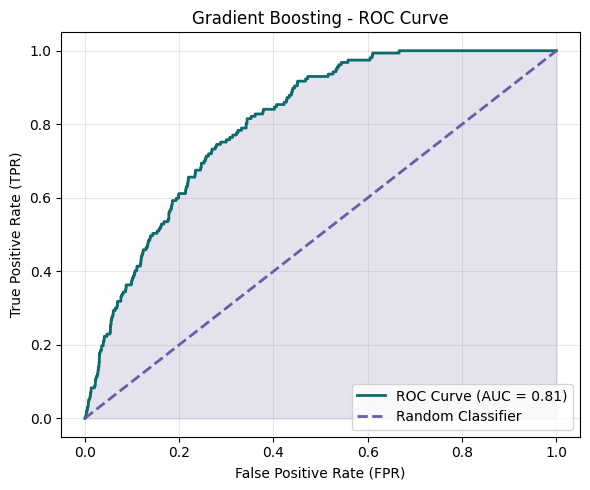

In [ ]:
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
roc_auc = auc(fpr_gb, tpr_gb)
plt.figure(figsize=(6,5))
# ROC Curve
plt.plot(fpr_gb, tpr_gb,
         color='#0f6b6b', linewidth=2,
         label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr_gb, tpr_gb,
                 color='#a7a1c2', alpha=0.3)
plt.plot([0,1], [0,1],
         color='#6b5ca5', linestyle='--', linewidth=2,
         label='Random Classifier')
# Labels & title
plt.title("Gradient Boosting - ROC Curve", fontsize=12)
plt.xlabel("False Positive Rate (FPR)", fontsize=10)
plt.ylabel("True Positive Rate (TPR)", fontsize=10)
plt.grid(alpha=0.3)
# Legend
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Tuning XGBoost model using GridSearchCV and evaluating classification performance.

In [ ]:
param_xgb = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}
grid_xgb = GridSearchCV(XGBClassifier(), param_xgb, cv=3, scoring='f1')
grid_xgb.fit(X_train_sm, y_train_sm)
best_xgb = grid_xgb.best_estimator_
print("Best XGB Params:", grid_xgb.best_params_)
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]
print("XGBoost (Tuned)\n")
print(classification_report(y_test, y_pred_xgb))

Best XGB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
XGBoost (Tuned)

              precision    recall  f1-score   support

           0       0.99      0.92      0.95      8523
           1       0.07      0.32      0.11       157

    accuracy                           0.91      8680
   macro avg       0.53      0.62      0.53      8680
weighted avg       0.97      0.91      0.94      8680



Visualizing confusion matrix for XGBoost model.

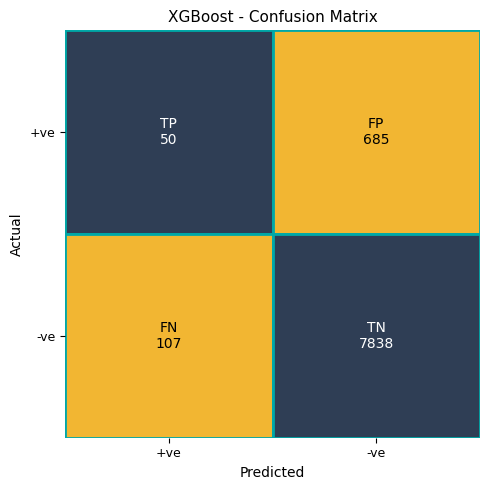

In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)
TN, FP, FN, TP = cm.ravel()
fig, ax = plt.subplots(figsize=(5,5))
# Colors
correct_color = "#2f3e55"
error_color = "#f2b632"
edge_color = "#00a8a8"
# TP (correct)
ax.add_patch(patches.Rectangle((0,1), 1, 1,
                               facecolor=correct_color,
                               edgecolor=edge_color, linewidth=2))
ax.text(0.5, 1.5, f"TP\n{TP}",
        ha='center', va='center', fontsize=10, color='white')

# FP (error)
ax.add_patch(patches.Rectangle((1,1), 1, 1,
                               facecolor=error_color,
                               edgecolor=edge_color, linewidth=2))
ax.text(1.5, 1.5, f"FP\n{FP}",
        ha='center', va='center', fontsize=10, color='black')
# FN (error)
ax.add_patch(patches.Rectangle((0,0), 1, 1,
                               facecolor=error_color,
                               edgecolor=edge_color, linewidth=2))
ax.text(0.5, 0.5, f"FN\n{FN}",
        ha='center', va='center', fontsize=10, color='black')

# TN (correct)
ax.add_patch(patches.Rectangle((1,0), 1, 1,
                               facecolor=correct_color,
                               edgecolor=edge_color, linewidth=2))
ax.text(1.5, 0.5, f"TN\n{TN}",
        ha='center', va='center', fontsize=10, color='white')
# Labels
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(['+ve', '-ve'], fontsize=9)
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(['-ve', '+ve'], fontsize=9)
ax.set_xlabel("Predicted", fontsize=10)
ax.set_ylabel("Actual", fontsize=10)
ax.set_title("XGBoost - Confusion Matrix", fontsize=11)
ax.set_xlim(0,2)
ax.set_ylim(0,2)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

Plotting ROC curve for XGBoost and evaluating AUC performance

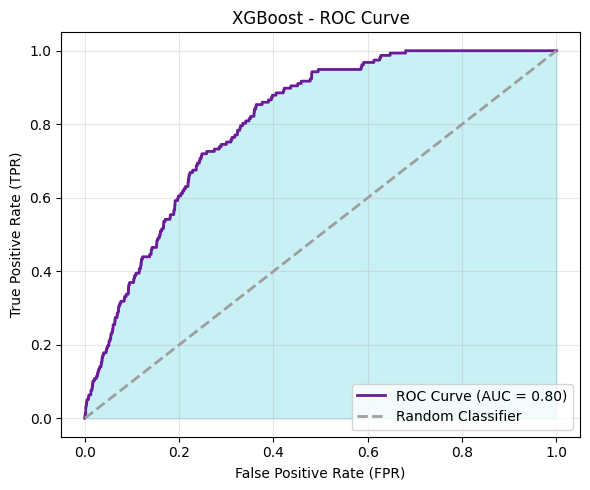

In [ ]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr_xgb, tpr_xgb)
plt.figure(figsize=(6,5))
# ROC Curve
plt.plot(fpr_xgb, tpr_xgb,
         color="#6a1b9a", linewidth=2,
         label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.fill_between(fpr_xgb, tpr_xgb,
                 color="#4dd0e1", alpha=0.3)
plt.plot([0,1], [0,1],
         color="#9e9e9e", linestyle='--', linewidth=2,
         label="Random Classifier")
# Labels & title
plt.title("XGBoost - ROC Curve", fontsize=12)
plt.xlabel("False Positive Rate (FPR)", fontsize=10)
plt.ylabel("True Positive Rate (TPR)", fontsize=10)
# Grid
plt.grid(alpha=0.3)
# Legend
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Comparing multiple models using performance metrics and summarizing results.

In [ ]:
results_df = pd.DataFrame({
    "Model": ["Logistic", "Random Forest", "Gradient Boosting", "XGBoost"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_xgb)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results_df = results_df.round(3)
print(results_df)

               Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0           Logistic     0.749      0.054   0.783     0.102    0.839
1      Random Forest     0.963      0.069   0.083     0.075    0.761
2  Gradient Boosting     0.940      0.082   0.229     0.121    0.807
3            XGBoost     0.909      0.068   0.318     0.112    0.805


Comparing model accuracies using horizontal bar chart visualization

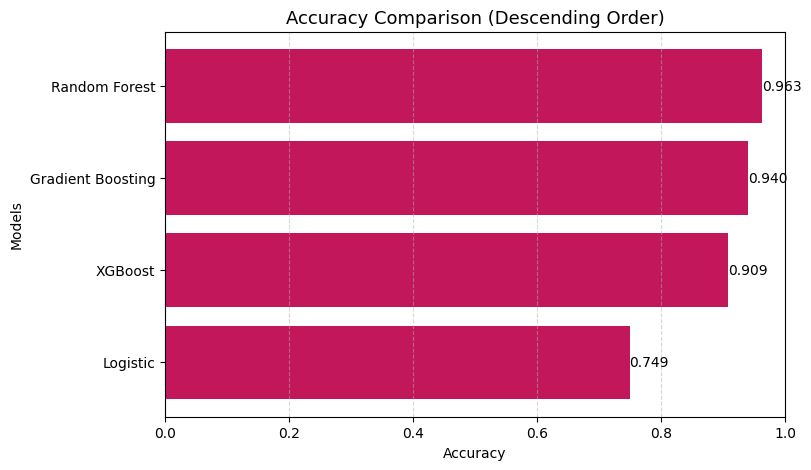

In [ ]:
data = pd.DataFrame({
    "Model": ["Logistic", "Random Forest", "Gradient Boosting", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb)
    ]
})
data = data.sort_values(by="Accuracy", ascending=False)
plt.figure(figsize=(8,5))
bars = plt.barh(data["Model"], data["Accuracy"], color='#C2185B')
# Labels
for i, v in enumerate(data["Accuracy"]):
    plt.text(v, i, f"{v:.3f}", va='center', fontsize=10)
plt.title("Accuracy Comparison (Descending Order)", fontsize=13)
plt.xlabel("Accuracy")
plt.ylabel("Models")
plt.xlim(0,1)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

Visualizing model performance metrics using heatmap for comparative analysis

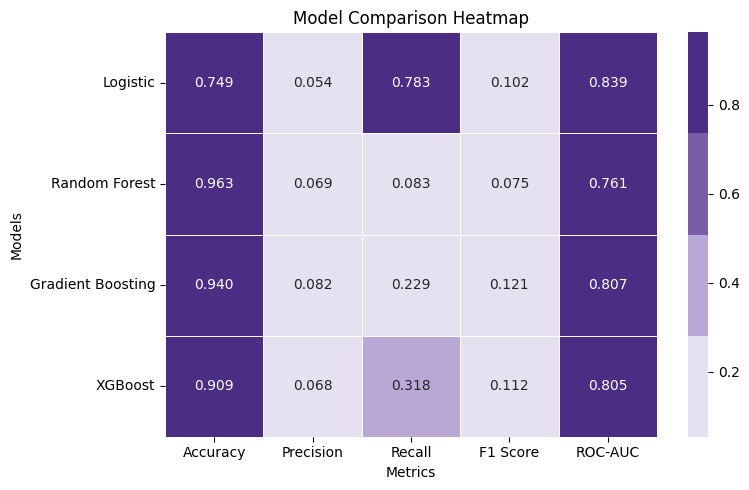

In [ ]:
plt.figure(figsize=(8,5))
custom_cmap = sns.color_palette(
    ["#e6e1f0", "#b9a7d6", "#7a5ca5", "#4b2e83"],
    as_cmap=True
)
sns.heatmap(
    results_df.set_index("Model"),
    annot=True,
    fmt=".3f",
    cmap=custom_cmap,
    linewidths=0.5,
    linecolor="white"
)
plt.title("Model Comparison Heatmap", fontsize=12)
plt.xlabel("Metrics", fontsize=10)
plt.ylabel("Models", fontsize=10)
plt.tight_layout()
plt.show()

Comparing ROC curves across models for evaluating classification performance

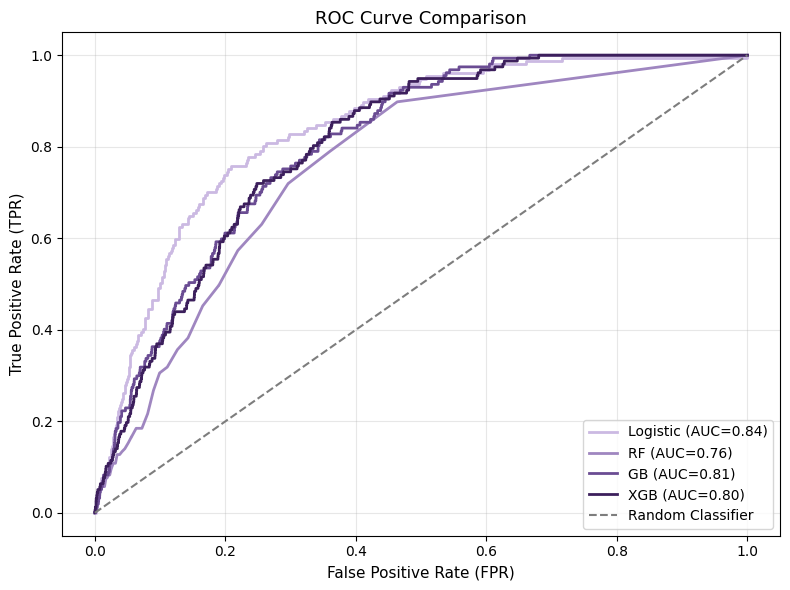

In [ ]:
plt.figure(figsize=(8,6))
colors = ["#cbb9e2", "#9f86c0", "#6a4c93", "#3c1f5c"]
plt.plot(fpr_lr, tpr_lr, color=colors[0], linewidth=2,
         label=f"Logistic (AUC={auc(fpr_lr,tpr_lr):.2f})")
plt.plot(fpr_rf, tpr_rf, color=colors[1], linewidth=2,
         label=f"RF (AUC={auc(fpr_rf,tpr_rf):.2f})")
plt.plot(fpr_gb, tpr_gb, color=colors[2], linewidth=2,
         label=f"GB (AUC={auc(fpr_gb,tpr_gb):.2f})")
plt.plot(fpr_xgb, tpr_xgb, color=colors[3], linewidth=2,
         label=f"XGB (AUC={auc(fpr_xgb,tpr_xgb):.2f})")

# Random classifier (baseline)
plt.plot([0,1], [0,1],
         linestyle='--', color='#7d7d7d', linewidth=1.5,
         label="Random Classifier")

# Labels & title
plt.title("ROC Curve Comparison", fontsize=13)
plt.xlabel("False Positive Rate (FPR)", fontsize=11)
plt.ylabel("True Positive Rate (TPR)", fontsize=11)
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Comparing precision recall curves across models for evaluating performance

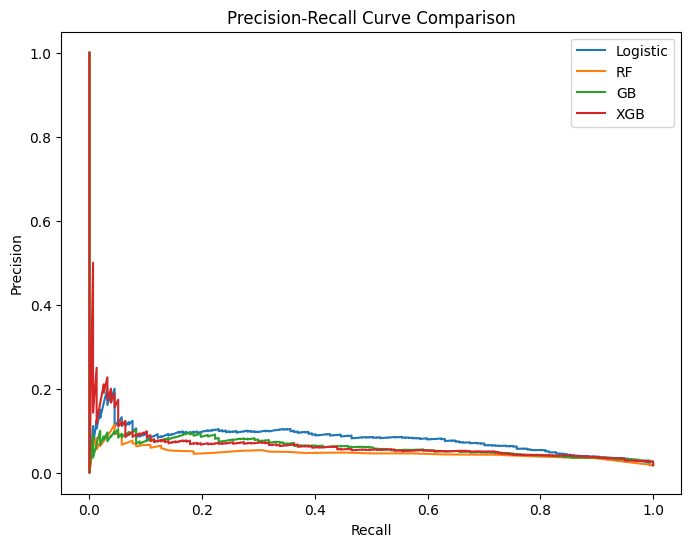

In [ ]:
plt.figure(figsize=(8,6))
for name, y_prob in {
    "Logistic": y_prob_lr,
    "RF": y_prob_rf,
    "GB": y_prob_gb,
    "XGB": y_prob_xgb
}.items():
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(recall, precision, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

Visualizing feature importance scores using bar chart for interpretation

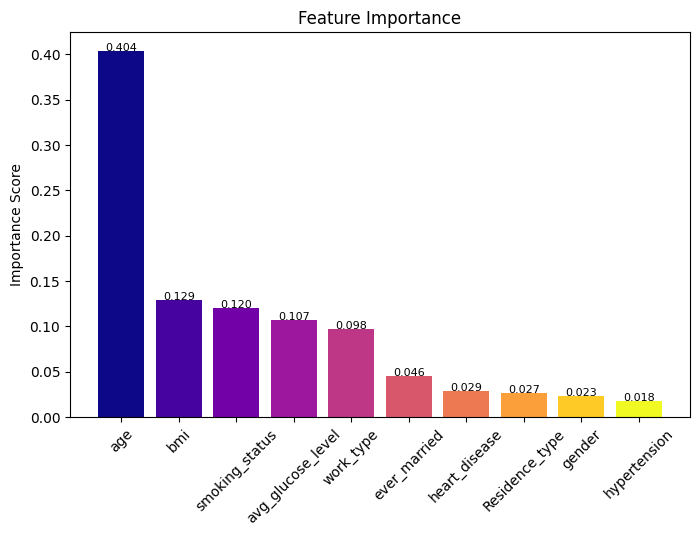

In [ ]:
importance = pd.Series(best_rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)
plt.figure(figsize=(8,5))
colors = plt.cm.plasma(np.linspace(0,1,len(importance)))
plt.bar(importance.index, importance.values, color=colors)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.ylabel("Importance Score")

# Adding values
for i, v in enumerate(importance.values):
    plt.text(i, v, f"{v:.3f}", ha='center', fontsize=8)
plt.show()